<a href="https://colab.research.google.com/github/tpedCode/P07/blob/feat%2Fmodeling/notebooks/1_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implémentez un modèle de scoring**

### Objectif :
- prédire la probabilité de défaut d’un client
- optimiser un seuil métier (coût FN > FP)
- préparer un modèle pour une API

### **Initialisation**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =========================================
# INSTALLATION DES DÉPENDANCES
# =========================================

!pip install mlflow -q
!pip install pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/

In [5]:
# =========================================
# IMPORTS
# =========================================

# -------- Data --------
import pandas as pd
import numpy as np

# -------- System --------
import os
import gc
import shutil

# -------- Viz --------
import matplotlib.pyplot as plt

# -------- MLflow --------
import mlflow
import mlflow.sklearn

# -------- Sklearn --------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

# -------- Metrics --------
from sklearn.metrics import roc_auc_score, confusion_matrix

In [6]:
# =========================================
# PATHS
# =========================================

BASE_PATH = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/data/"

# Chemins de données
RAW_PATH = os.path.join(BASE_PATH, "raw/")
PROCESSED_PATH = os.path.join(BASE_PATH, "processed/")

print(RAW_PATH)
print(PROCESSED_PATH)

/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/data/raw/
/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/data/processed/


In [7]:
# =========================================
# LOAD DATA
# =========================================

def load_csv(name):
    return pd.read_csv(os.path.join(RAW_PATH, name))

application_train = load_csv("application_train.csv")
application_test = load_csv("application_test.csv")

bureau = load_csv("bureau.csv")
bureau_balance = load_csv("bureau_balance.csv")

credit_card_balance = load_csv("credit_card_balance.csv")
installments_payments = load_csv("installments_payments.csv")
pos_cash_balance = load_csv("POS_CASH_balance.csv")
previous_application = load_csv("previous_application.csv")

sample_submission = load_csv("sample_submission.csv")

homecredit_columns_description = pd.read_csv(
    os.path.join(RAW_PATH, "HomeCredit_columns_description.csv"),
    encoding="latin1"
)

### **Fonctions génériques**

In [8]:
def eda(
    df,
    name=None,

    # Blocs
    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    # Cat detail
    cat_detail_cols=None,

    # Graphs
    show_barplots=False,
    barplot_cols=None,

    show_boxplots=False,
    boxplot_cols=None,

    top_n=20
):

    if name is None:
        name_found = [k for k, v in globals().items() if v is df]
        name = name_found[0] if name_found else "DataFrame"

    print("\n" + "=" * 60)
    print(f"EDA : {name.upper()}")
    print("=" * 60)

    # ===== GENERAL =====
    if show_general:
        print("\n-----GENERAL------------------------------------------------")
        print(f"Shape : {df.shape}")
        print(f"Nb colonnes : {len(df.columns)}")

        print("\nColonnes :")
        print(df.columns.tolist())

        print("\nAperçu :")
        display(df.head())

    # ===== DATA QUALITY =====
    if show_quality:
        print("\n" + "-" * 60)
        print("DATA QUALITY")
        print("-" * 60)

        num_cols = df.select_dtypes(include=np.number).columns

        summary = pd.DataFrame(index=df.columns)
        summary["dtype"] = df.dtypes
        summary["missing_%"] = (df.isnull().mean() * 100).round(2)
        summary["n_unique"] = df.nunique()

        zero_pct = pd.Series(index=df.columns, dtype=float)
        zero_pct[num_cols] = (df[num_cols] == 0).mean() * 100
        summary["zero_%"] = zero_pct.fillna(0).round(2)

        summary["top_freq_%"] = (
            df.apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100)
        ).round(2)

        display(summary.sort_values("missing_%", ascending=False))

    # ===== NUMERICAL =====
    if show_numerical:
        print("\n" + "-" * 60)
        print("NUMERICAL VARIABLES")
        print("-" * 60)

        num_cols = df.select_dtypes(include=np.number).columns
        display(df[num_cols].describe().T.round(2))

    # ===== CATEGORICAL =====
    if show_categorical:

        cat_cols = df.select_dtypes(include="object").columns

        if len(cat_cols) > 0:
            print("\n" + "-" * 60)
            print("CATEGORICAL VARIABLES")
            print("-" * 60)

            cat_summary = pd.DataFrame({
                "n_unique": df[cat_cols].nunique()
            }).sort_values(by="n_unique", ascending=False)

            display(cat_summary)

            if cat_detail_cols:
                print("\n--- Détail variables catégorielles ---")

                for col in cat_detail_cols:
                    if col in df.columns:
                        print(f"\n{col}")
                        display(
                            df[col]
                            .value_counts(normalize=True)
                            .round(2)
                            .head(top_n)
                        )

    # ===== BARPLOTS =====
    if show_barplots and barplot_cols:
        print("\n" + "-" * 60)
        print("BARPLOTS")
        print("-" * 60)

        for col in barplot_cols:
            if col in df.columns:
                plt.figure()

                counts_abs = df[col].value_counts().head(top_n)
                counts_pct = (counts_abs / len(df) * 100).round(2)

                ax = counts_pct.plot(kind="bar")

                plt.title(col)
                plt.ylabel("%")
                plt.xticks(rotation=90)

                for i, val in enumerate(counts_abs):
                    plt.text(
                        i,
                        counts_pct.iloc[i],
                        f"{val}",
                        ha="center",
                        va="bottom"
                    )

                plt.tight_layout()
                plt.show()

    # ===== BOXPLOTS =====
    if show_boxplots and boxplot_cols:
        print("\n" + "-" * 60)
        print("BOXPLOTS")
        print("-" * 60)

        for col in boxplot_cols:
            if col in df.columns and np.issubdtype(df[col].dtype, np.number):
                plt.figure()
                df.boxplot(column=col)
                plt.title(col)
                plt.tight_layout()
                plt.show()

In [9]:
def get_doc(df_desc, column, table=None):
    """
    Affiche la description d'une colonne.

    Params:
    - df_desc : dataframe des descriptions
    - column : nom de la colonne
    - table : optionnel, nom de la table pour filtrer
    """

    result = df_desc[df_desc["Row"] == column]

    if table is not None:
        result = result[result["Table"] == table]

    print("\n" + "=" * 80)
    print(f"DOCUMENTATION : {column.upper()}")
    print("=" * 80)

    if result.empty:
        print("Aucune description trouvée")
        return

    for _, row in result.iterrows():
        print("\n" + "-" * 80)
        print(f"Table       : {row['Table']}")
        print(f"Colonne     : {row['Row']}")
        print("Description :")
        print(row["Description"])

# get_doc(homecredit_columns_description, "AMT_CREDIT")
# get_doc(homecredit_columns_description, "AMT_CREDIT", "application_train.csv")

In [10]:
def one_hot_encoder(df):
    categorical_cols = df.select_dtypes(include="object").columns      # variables catégorielles
    df = pd.get_dummies(df, columns=categorical_cols, dummy_na=True)   # encodage
    return df

## **1. EXPLORATORY DATA ANALYSIS**


EDA : APPLICATION_TRAIN

-----GENERAL------------------------------------------------
Shape : (307511, 122)
Nb colonnes : 122

Colonnes :
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EX

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
COMMONAREA_AVG,float64,69.87,3181,2.75,9.11
COMMONAREA_MODE,float64,69.87,3128,3.15,10.46
COMMONAREA_MEDI,float64,69.87,3202,2.83,9.38
NONLIVINGAPARTMENTS_MEDI,float64,69.43,214,18.24,59.68
NONLIVINGAPARTMENTS_MODE,float64,69.43,167,19.27,63.04
...,...,...,...,...,...
FLAG_DOCUMENT_16,int64,0.00,2,99.01,99.01
FLAG_DOCUMENT_15,int64,0.00,2,99.88,99.88
FLAG_DOCUMENT_14,int64,0.00,2,99.71,99.71
FLAG_DOCUMENT_20,int64,0.00,2,99.95,99.95



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


...


NAME_EDUCATION_TYPE


,proportion
NAME_EDUCATION_TYPE,
Secondary / secondary special,0.71
Higher education,0.24
Incomplete higher,0.03
Lower secondary,0.01
Academic degree,0.00



ORGANIZATION_TYPE


,proportion
ORGANIZATION_TYPE,
Business Entity Type 3,0.22
XNA,0.18
Self-employed,0.12
Other,0.05
Medicine,0.04
Business Entity Type 2,0.03
Government,0.03
School,0.03
Trade: type 7,0.03



------------------------------------------------------------
BARPLOTS
------------------------------------------------------------


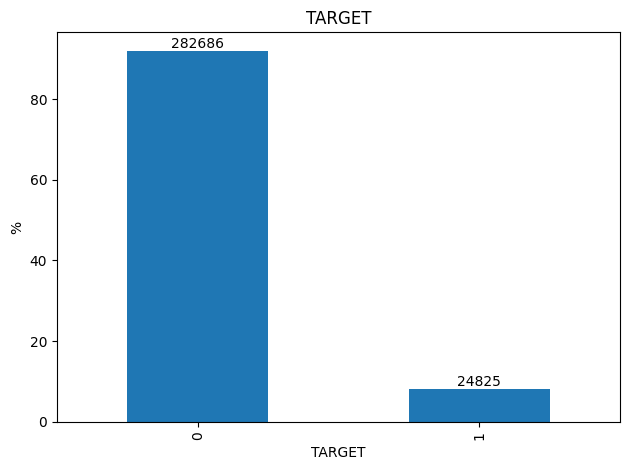


------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


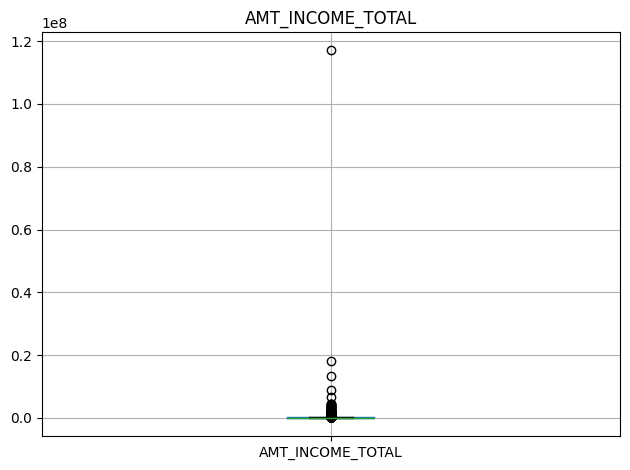

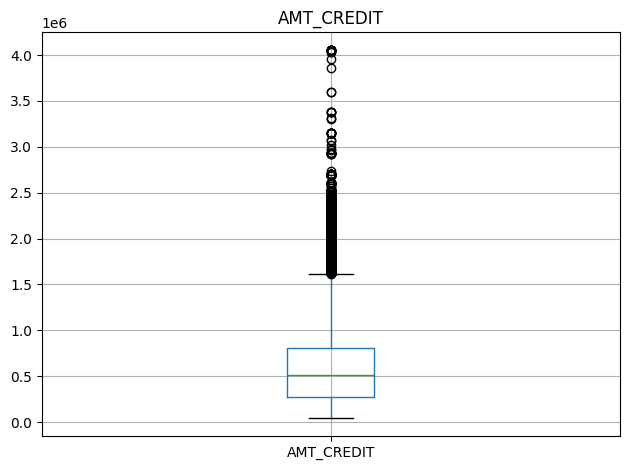

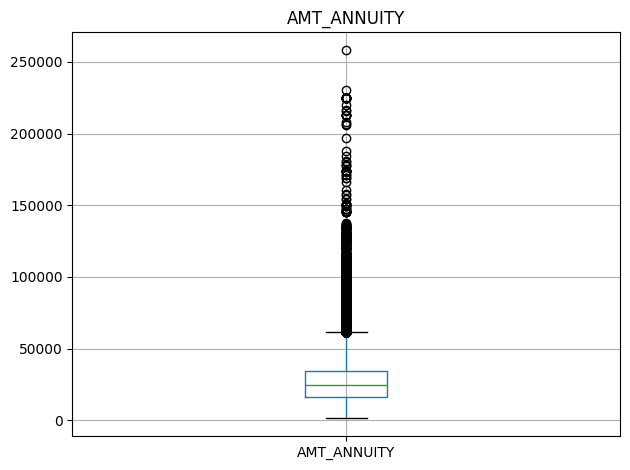

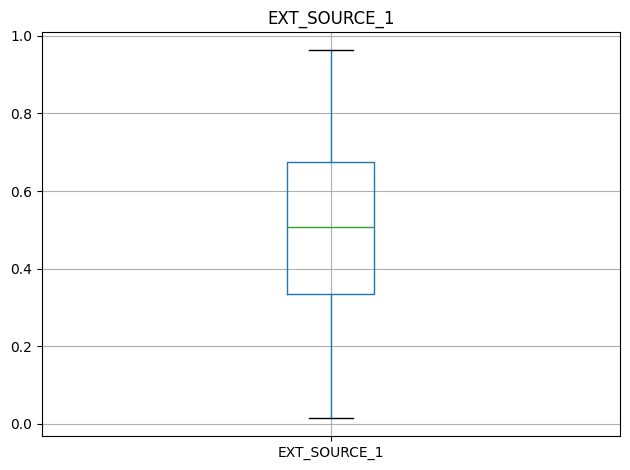

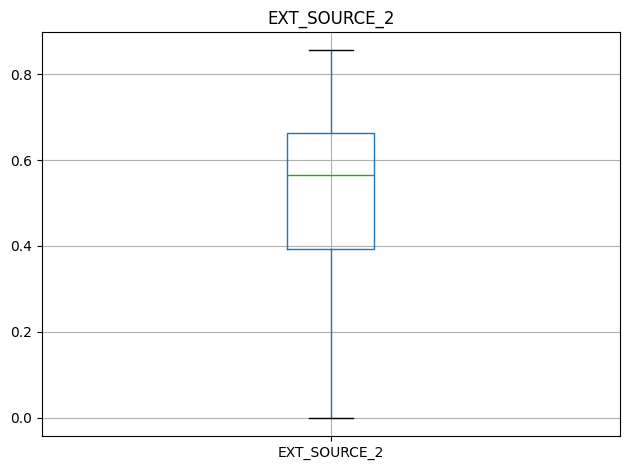

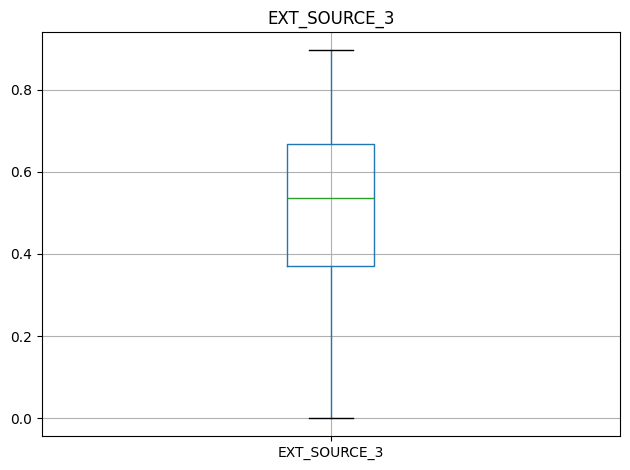

In [ ]:
eda(
    application_train,
    name="application_train",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "NAME_CONTRACT_TYPE",
        "CODE_GENDER",
        "NAME_INCOME_TYPE",
        "NAME_FAMILY_STATUS",
        "NAME_EDUCATION_TYPE",
        "ORGANIZATION_TYPE"
    ],

    show_barplots=True,
    barplot_cols=["TARGET"],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
)

In [ ]:
eda(
    application_test,
    name="application_test",

    show_general=True,
    show_quality=True,
    show_numerical=False,
    show_categorical=False
)


EDA : APPLICATION_TEST

-----GENERAL------------------------------------------------
Shape : (48744, 121)
Nb colonnes : 121

Colonnes :
['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
COMMONAREA_AVG,float64,68.72,2042,2.82,9.00
COMMONAREA_MEDI,float64,68.72,2034,2.92,9.34
COMMONAREA_MODE,float64,68.72,2001,3.29,10.52
NONLIVINGAPARTMENTS_AVG,float64,68.41,241,18.08,57.25
NONLIVINGAPARTMENTS_MEDI,float64,68.41,134,18.70,59.21
...,...,...,...,...,...
FLAG_DOCUMENT_16,int64,0.00,1,100.00,100.00
FLAG_DOCUMENT_15,int64,0.00,1,100.00,100.00
FLAG_DOCUMENT_14,int64,0.00,1,100.00,100.00
FLAG_DOCUMENT_20,int64,0.00,1,100.00,100.00


In [ ]:
eda(
    bureau_balance,
    name="bureau_balance",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=["STATUS"]
)


EDA : BUREAU_BALANCE

-----GENERAL------------------------------------------------
Shape : (27299925, 3)
Nb colonnes : 3

Colonnes :
['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

Aperçu :


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
SK_ID_BUREAU,int64,0.0,817395,0.00,0.00
MONTHS_BALANCE,int64,0.0,97,2.24,2.28
STATUS,object,0.0,8,0.00,49.99



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_BUREAU,27299925.0,6036297.33,492348.86,5001709.0,5730933.0,6070821.0,6431951.0,6842888.0
MONTHS_BALANCE,27299925.0,-30.74,23.86,-96.0,-46.0,-25.0,-11.0,0.0



------------------------------------------------------------
CATEGORICAL VARIABLES
------------------------------------------------------------


,n_unique
STATUS,8



--- Détail variables catégorielles ---

STATUS


,proportion
STATUS,
C,0.50
0,0.27
X,0.21
1,0.01
5,0.00
2,0.00
3,0.00
4,0.00



EDA : BUREAU

-----GENERAL------------------------------------------------
Shape : (1716428, 17)
Nb colonnes : 17

Colonnes :
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

Aperçu :


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
AMT_ANNUITY,float64,71.47,40321,14.97,52.47
AMT_CREDIT_MAX_OVERDUE,float64,65.51,68251,27.42,79.51
DAYS_ENDDATE_FACT,float64,36.92,2917,0.00,0.07
AMT_CREDIT_SUM_LIMIT,float64,34.48,51726,61.18,93.38
AMT_CREDIT_SUM_DEBT,float64,15.01,226537,59.22,69.68
DAYS_CREDIT_ENDDATE,float64,6.15,14096,0.05,0.05
SK_ID_CURR,int64,0.00,305811,0.00,0.01
DAYS_CREDIT,int64,0.00,2923,0.00,0.08
SK_ID_BUREAU,int64,0.00,1716428,0.00,0.00
CREDIT_DAY_OVERDUE,int64,0.00,942,99.75,99.75



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


...


--- Détail variables catégorielles ---

CREDIT_ACTIVE


,proportion
CREDIT_ACTIVE,
Closed,0.63
Active,0.37
Sold,0.00
Bad debt,0.00



CREDIT_TYPE


,proportion
CREDIT_TYPE,
Consumer credit,0.73
Credit card,0.23
Car loan,0.02
Mortgage,0.01
Microloan,0.01
Loan for business development,0.00
Another type of loan,0.00
Unknown type of loan,0.00
Loan for working capital replenishment,0.00



------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


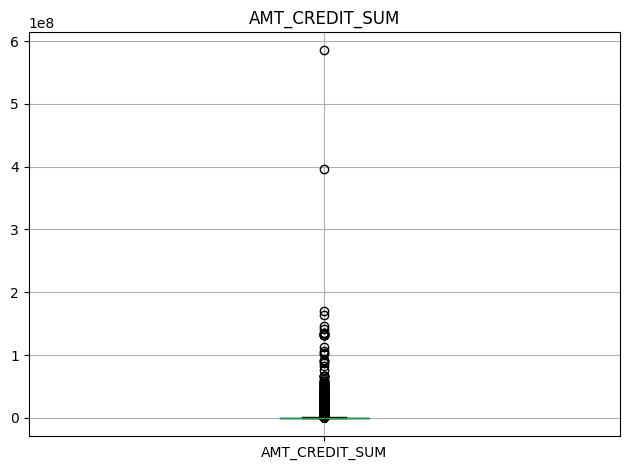

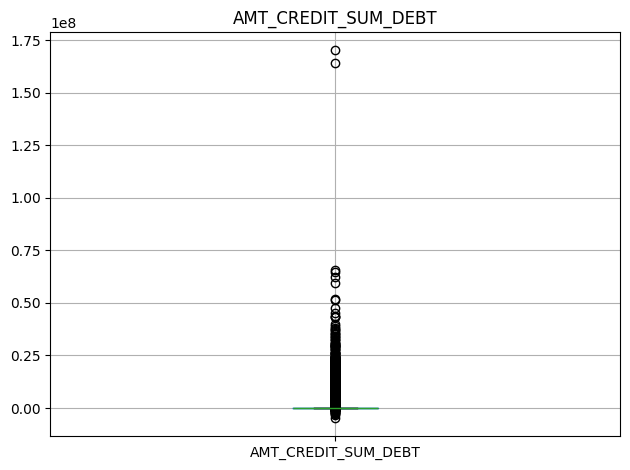

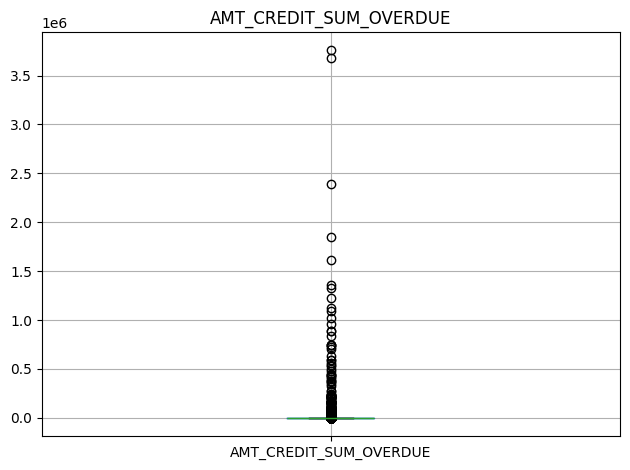

In [ ]:
eda(
    bureau,
    name="bureau",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "CREDIT_ACTIVE",
        "CREDIT_TYPE"
    ],

    show_barplots=False,
    show_boxplots=True,
    boxplot_cols=[
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_OVERDUE"
    ]
)


EDA : CREDIT_CARD_BALANCE

-----GENERAL------------------------------------------------
Shape : (3840312, 23)
Nb colonnes : 23

Colonnes :
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

Aperçu :


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
AMT_PAYMENT_CURRENT,float64,20.00,163209,10.17,12.71
CNT_DRAWINGS_POS_CURRENT,float64,19.52,133,73.58,91.43
AMT_DRAWINGS_ATM_CURRENT,float64,19.52,2267,69.41,86.26
CNT_DRAWINGS_ATM_CURRENT,float64,19.52,44,69.41,86.26
AMT_DRAWINGS_POS_CURRENT,float64,19.52,168748,73.58,91.43
AMT_DRAWINGS_OTHER_CURRENT,float64,19.52,1832,80.15,99.60
CNT_DRAWINGS_OTHER_CURRENT,float64,19.52,11,80.14,99.59
CNT_INSTALMENT_MATURE_CUM,float64,7.95,121,14.36,15.60
AMT_INST_MIN_REGULARITY,float64,7.95,312266,50.23,54.56
AMT_DRAWINGS_CURRENT,float64,0.00,187005,83.94,83.94



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


...


------------------------------------------------------------
CATEGORICAL VARIABLES
------------------------------------------------------------


,n_unique
NAME_CONTRACT_STATUS,7



--- Détail variables catégorielles ---

NAME_CONTRACT_STATUS


,proportion
NAME_CONTRACT_STATUS,
Active,0.96
Completed,0.03
Signed,0.00
Demand,0.00
Sent proposal,0.00
Refused,0.00
Approved,0.00



------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


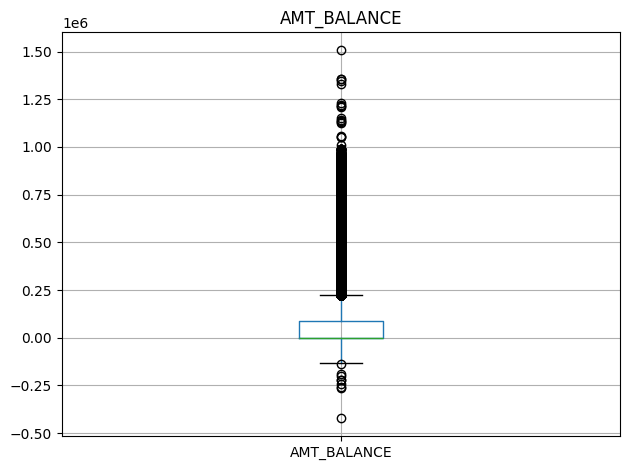

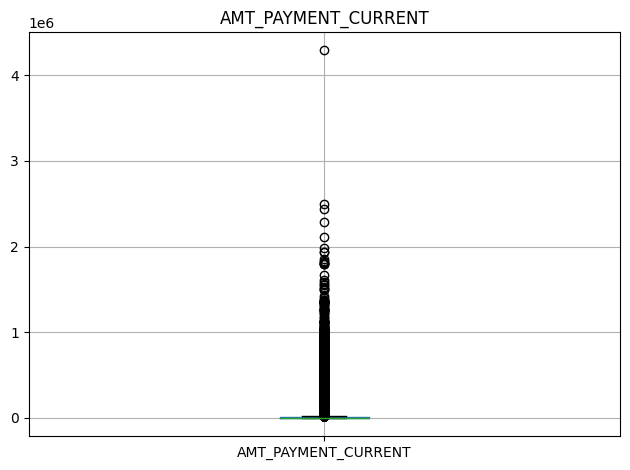

In [ ]:
eda(
    credit_card_balance,
    name="credit_card_balance",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=["NAME_CONTRACT_STATUS"],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_BALANCE",
        "AMT_PAYMENT_CURRENT"
    ]
)

In [ ]:
eda(
    homecredit_columns_description,
    name="homecredit_columns_description",

    show_general=True,
    show_quality=np.format_float_scientific,
    show_numerical=False,
    show_categorical=False
)

get_doc(homecredit_columns_description, "AMT_CREDIT")


EDA : HOMECREDIT_COLUMNS_DESCRIPTION

-----GENERAL------------------------------------------------
Shape : (219, 5)
Nb colonnes : 5

Colonnes :
['Unnamed: 0', 'Table', 'Row', 'Description', 'Special']

Aperçu :


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
Special,object,60.73,7,0.0,61.63
Unnamed: 0,int64,0.00,219,0.0,0.46
Table,object,0.00,7,0.0,55.71
Row,object,0.00,196,0.0,2.74
Description,object,0.00,163,0.0,21.46



DOCUMENTATION : AMT_CREDIT

--------------------------------------------------------------------------------
Table       : application_{train|test}.csv
Colonne     : AMT_CREDIT
Description :
Credit amount of the loan

--------------------------------------------------------------------------------
Table       : previous_application.csv
Colonne     : AMT_CREDIT
Description :
Final credit amount on the previous application. This differs from AMT_APPLICATION in a way that the AMT_APPLICATION is the amount for which the client initially applied for, but during our approval process he could have received different amount - AMT_CREDIT



EDA : INSTALLMENTS_PAYMENTS

-----GENERAL------------------------------------------------
Shape : (13605401, 8)
Nb colonnes : 8

Colonnes :
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']

Aperçu :


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
AMT_PAYMENT,float64,0.02,944235,0.01,1.83
DAYS_ENTRY_PAYMENT,float64,0.02,3039,0.00,0.10
SK_ID_PREV,int64,0.00,997752,0.00,0.00
SK_ID_CURR,int64,0.00,339587,0.00,0.00
NUM_INSTALMENT_NUMBER,int64,0.00,277,0.00,7.38
NUM_INSTALMENT_VERSION,float64,0.00,65,30.01,62.36
DAYS_INSTALMENT,float64,0.00,2922,0.00,0.08
AMT_INSTALMENT,float64,0.00,902539,0.00,1.87



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,13605401.0,1903364.97,536202.91,1000001.0,1434191.00,1896520.00,2369094.00,2843499.00
SK_ID_CURR,13605401.0,278444.88,102718.31,100001.0,189639.00,278685.00,367530.00,456255.00
NUM_INSTALMENT_VERSION,13605401.0,0.86,1.04,0.0,0.00,1.00,1.00,178.00
NUM_INSTALMENT_NUMBER,13605401.0,18.87,26.66,1.0,4.00,8.00,19.00,277.00
DAYS_INSTALMENT,13605401.0,-1042.27,800.95,-2922.0,-1654.00,-818.00,-361.00,-1.00
DAYS_ENTRY_PAYMENT,13602496.0,-1051.11,800.59,-4921.0,-1662.00,-827.00,-370.00,-1.00
AMT_INSTALMENT,13605401.0,17050.91,50570.25,0.0,4226.08,8884.08,16710.21,3771487.84
AMT_PAYMENT,13602496.0,17238.22,54735.78,0.0,3398.26,8125.52,16108.42,3771487.84



------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


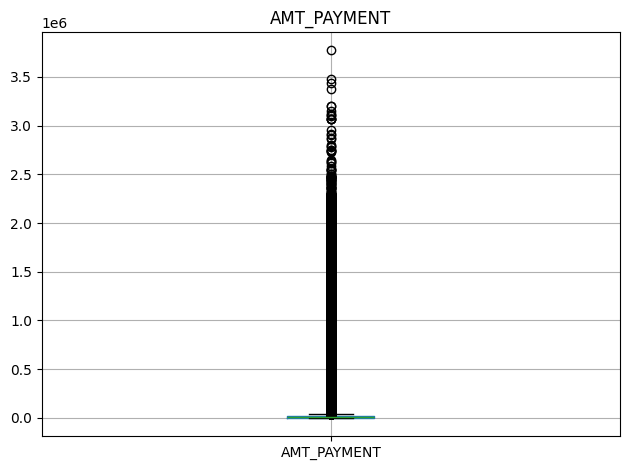

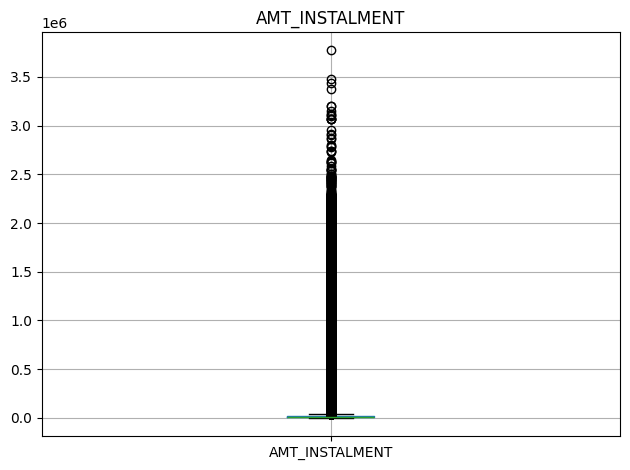

In [ ]:
eda(
    installments_payments,
    name="installments_payments",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=False,

    show_boxplots=True,
    boxplot_cols=[
        "AMT_PAYMENT",
        "AMT_INSTALMENT"
    ]
)

In [ ]:
eda(
    pos_cash_balance,
    name="pos_cash_balance",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=["NAME_CONTRACT_STATUS"]
)


EDA : POS_CASH_BALANCE

-----GENERAL------------------------------------------------
Shape : (10001358, 8)
Nb colonnes : 8

Colonnes :
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

Aperçu :


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
CNT_INSTALMENT,float64,0.26,73,0.00,25.03
CNT_INSTALMENT_FUTURE,float64,0.26,79,11.86,11.89
SK_ID_CURR,int64,0.00,337252,0.00,0.00
SK_ID_PREV,int64,0.00,936325,0.00,0.00
MONTHS_BALANCE,int64,0.00,96,0.00,2.16
NAME_CONTRACT_STATUS,object,0.00,9,0.00,91.50
SK_DPD,int64,0.00,3400,97.05,97.05
SK_DPD_DEF,int64,0.00,2307,98.86,98.86



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,10001358.0,1903216.60,535846.53,1000001.0,1434405.0,1896565.0,2368963.0,2843499.0
SK_ID_CURR,10001358.0,278403.86,102763.75,100001.0,189550.0,278654.0,367429.0,456255.0
MONTHS_BALANCE,10001358.0,-35.01,26.07,-96.0,-54.0,-28.0,-13.0,-1.0
CNT_INSTALMENT,9975287.0,17.09,12.00,1.0,10.0,12.0,24.0,92.0
CNT_INSTALMENT_FUTURE,9975271.0,10.48,11.11,0.0,3.0,7.0,14.0,85.0
SK_DPD,10001358.0,11.61,132.71,0.0,0.0,0.0,0.0,4231.0
SK_DPD_DEF,10001358.0,0.65,32.76,0.0,0.0,0.0,0.0,3595.0



------------------------------------------------------------
CATEGORICAL VARIABLES
------------------------------------------------------------


,n_unique
NAME_CONTRACT_STATUS,9



--- Détail variables catégorielles ---

NAME_CONTRACT_STATUS


,proportion
NAME_CONTRACT_STATUS,
Active,0.91
Completed,0.07
Signed,0.01
Demand,0.00
Returned to the store,0.00
Approved,0.00
Amortized debt,0.00
Canceled,0.00
XNA,0.00



EDA : PREVIOUS_APPLICATION

-----GENERAL------------------------------------------------
Shape : (1670214, 37)
Nb colonnes : 37

Colonnes :
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

Aperçu :


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
RATE_INTEREST_PRIVILEGED,float64,99.64,25,0.00,28.85
RATE_INTEREST_PRIMARY,float64,99.64,148,0.00,20.47
AMT_DOWN_PAYMENT,float64,53.64,29278,22.14,47.76
RATE_DOWN_PAYMENT,float64,53.64,207033,22.14,47.76
NAME_TYPE_SUITE,object,49.12,7,0.00,59.89
DAYS_TERMINATION,float64,40.30,2830,0.00,22.66
DAYS_FIRST_DRAWING,float64,40.30,2838,0.00,93.71
DAYS_FIRST_DUE,float64,40.30,2892,0.00,4.08
DAYS_LAST_DUE_1ST_VERSION,float64,40.30,4605,0.04,9.41
DAYS_LAST_DUE,float64,40.30,2873,0.00,21.18



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


...


NAME_CLIENT_TYPE


,proportion
NAME_CLIENT_TYPE,
Repeater,0.74
New,0.18
Refreshed,0.08
XNA,0.00



NAME_GOODS_CATEGORY


,proportion
NAME_GOODS_CATEGORY,
XNA,0.57
Mobile,0.13
Consumer Electronics,0.07
Computers,0.06
Audio/Video,0.06
Furniture,0.03
Photo / Cinema Equipment,0.01
Construction Materials,0.01
Clothing and Accessories,0.01



------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


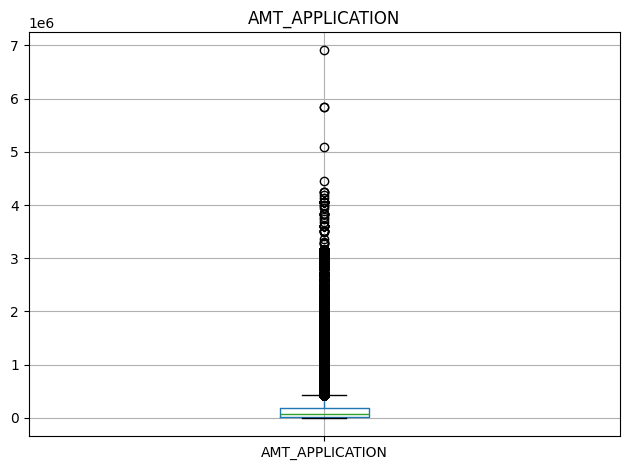

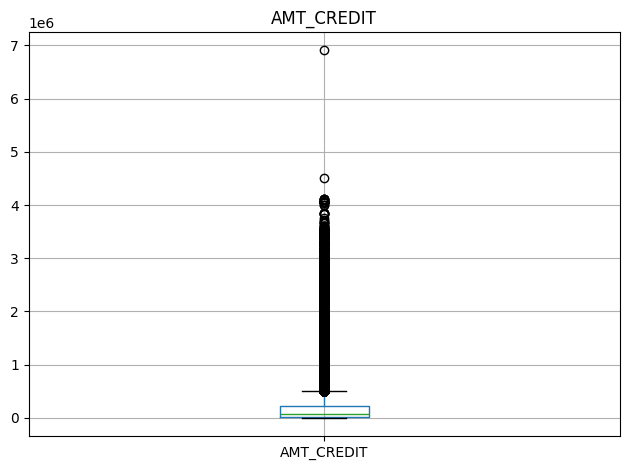

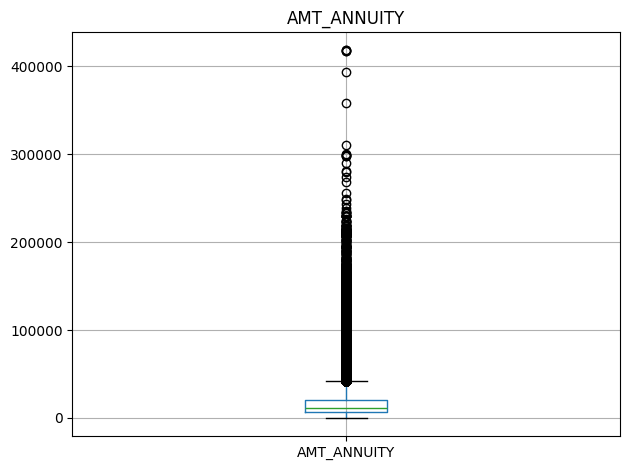

In [ ]:
eda(
    previous_application,
    name="previous_application",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "NAME_CONTRACT_STATUS",
        "NAME_CLIENT_TYPE",
        "NAME_GOODS_CATEGORY"
    ],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_APPLICATION",
        "AMT_CREDIT",
        "AMT_ANNUITY"
    ]
)

In [ ]:
eda(
    sample_submission,
    name="sample_submission",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=False
)


EDA : SAMPLE_SUBMISSION

-----GENERAL------------------------------------------------
Shape : (48744, 2)
Nb colonnes : 2

Colonnes :
['SK_ID_CURR', 'TARGET']

Aperçu :


,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
SK_ID_CURR,int64,0.0,48744,0.0,0.0
TARGET,float64,0.0,1,0.0,100.0



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,277796.68,103169.55,100001.0,188557.75,277549.0,367555.5,456250.0
TARGET,48744.0,0.50,0.00,0.5,0.50,0.5,0.5,0.5


### **1. Synthèse globale**

#### **1.1. Structure du dataset**

* Dataset **relationnel multi-tables**, centré sur `application_train`
* Granularité différente selon les tables :
  * client (`application_train`)
  * crédit historique (`bureau`, `previous_application`)
  * transactions (`installments`, `credit_card`, `POS`)
* Clés principales :
  * `SK_ID_CURR` → client
  * `SK_ID_PREV` / `SK_ID_BUREAU` → crédits


#### **1.2. Qualité globale des données**

* **Beaucoup de missing values** sur certaines familles :
  * features logement (`_AVG`, `_MODE`, `_MEDI`) → \~70%
  * variables finance secondaires (bureau, previous)
* **Colonnes très déséquilibrées / constantes**
  * flags documents → quasi inutiles
  * certaines variables catégorielles dominées par une seule modalité
* **Outliers importants** sur montants (revenus, crédits)
* Variables fortement asymétriques


#### **1.3. Signaux métier importants**

* Target déséquilibrée (\~8%)
* Historique crédit présent sur plusieurs tables → **opportunité feature engineering**
* Variables externes (`EXT_SOURCE`) probablement très prédictives
* Données temporelles négatives (jours relatifs) → nécessite transformation


### **2. Synthèse par table**


#### **2.1. application\_train : table principale de modélisation**

**Points clés :**

* 307k lignes, 122 variables
* Target binaire déséquilibrée (\~8%)
* Profil clients :
  * majorité “Cash loans”
  * majorité revenus “Working”
  * majorité mariés
* Variables importantes :
  * `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`
  * `EXT_SOURCE_1/2/3`

**Problèmes :**

* Très forte proportion de missing sur variables logement (\~70%)
* Beaucoup de variables inutiles :
  * `FLAG_DOCUMENT_X`
* variance faible sur certaines colonnes binaires

**Opportunités :**

* forte richesse de variables catégorielles
* bonnes candidates pour encoding
* création de ratios :
  * crédit / revenu
  * annuité / revenu


#### **2.2. application\_test : équivalent du train sans target**

**Points clés :**

* structure identique
* même problématique de missing

**Usage :**

* transformation identique au train


#### **2.3 bureau**

**Rôle : historique crédit externe (crédit bureau)**

**Points clés :**

* 1.7M lignes
* 63% crédits CLOSED, 37% ACTIVE
* types dominants :
  * Consumer credit (73%)
  * Credit card (23%)

**Problèmes :**

* missing élevés :
  * `AMT_ANNUITY`, `AMT_CREDIT_MAX_OVERDUE`
* variables peu informatives (overdue très souvent 0)

**Opportunités :**

* agrégation par client :
  * nombre de crédits actifs
  * dette totale
  * ratio dette / crédit
  * historique de défaut


#### **2.4. bureau\_balance : historique mensuel des crédits bureau**

**Points clés :**

* table volumineuse (\~27M lignes)
* `STATUS` très informatif :
  * C (closed) \~50%
  * 0 (no delay) \~27%
  * X (unknown) \~21%

**Opportunités :**

* feature temporelle :
  * nombre de mois en défaut
  * worst status
* enrichissement bureau


#### **2.5. previous\_application : historique des demandes de crédit internes**

**Points clés :**

* 1.6M lignes
* statuts :
  * Approved (\~62%)
  * Canceled (\~19%)
  * Refused (\~17%)
* clients :
  * repeater majoritaire (\~74%)

**Problèmes :**

* énormément de missing (jusqu’à 99% sur certaines variables)
* variables financières partielles

**Opportunités :**

* comportements passés :
  * taux de refus
  * nb d'applications
  * profil client historique


#### **2.6. credit\_card\_balance : historique cartes de crédit**

**Points clés :**

* 3.8M lignes
* 96% des contrats “Active”

**Problèmes :**

* beaucoup de variables à 0 dominant
* missing modéré (\~20% sur certaines variables)

**Opportunités :**

* indicateurs comportement :
  * utilisation du crédit
  * paiements
  * dépassements


#### **2.7. installments\_payments : historique des remboursements**

**Points clés :**

* 13.6M lignes
* données complètes (quasi pas de missing)

**Opportunités majeures :**

* calcul du retard :
  * `DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`
* indicateurs :
  * retards moyens
  * fréquence des retards
  * écart paiement vs dû


#### **2.8. POS\_CASH\_balance : crédits POS (point of sale)**

**Points clés :**

* 10M lignes
* majorité ACTIVE (\~91%)

**Problèmes :**

* variables fortement dominées (DPD = 0)

**Opportunités :**

* comportement crédit court terme
* évolution remboursements


#### **2.9. sample\_submission : template de soumission**

**Aucun intérêt analytique**


#### **2.10. homecredit\_columns\_description : dictionnaire de données**

**Usage :**

* compréhension des variables uniquement


### **3. Conclusion opérationnelle**

#### **3.1. Points forts du dataset**

* richesse des sources (multi-tables)
* historique complet client
* données comportementales détaillées


#### **3.2. Points faibles**

* beaucoup de missing structurés
* nombreuses variables inutiles
* nécessité d’agrégations complexes


#### **3.3. Directions ML prioritaires**

* Nettoyage :
  * suppression variables très manquantes / constantes
* Feature engineering :
  * agrégations multi-tables
  * variables retard paiement
  * ratios financiers
* Encodage catégoriel
* gestion du déséquilibre target

## **2. SETUP MLFLOW**

### **2.1. Configuration**

In [11]:
# Reset (optionel)
MLFLOW_PATH = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/mlflow"

if os.path.exists(MLFLOW_PATH):
    shutil.rmtree(MLFLOW_PATH)

print("MLflow reset")

MLflow reset


In [12]:
# Définition du stockage MLFLOW

EXPERIMENT_NAME = "home_credit_scoring_v1"                                                      # Nom de l'expérience MLflow (permet de versionner proprement)
MLFLOW_PATH = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/mlflow" # Chemin de stockage (Drive → persistant entre sessions) # Contiendra la DB MLflow + les modèles
os.makedirs(MLFLOW_PATH, exist_ok=True)                                                         # Création du dossier si non existant (évite les erreurs)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_PATH}/mlflow.db")                                   # Configuration du tracking MLflow : SQLite locale = stockage des runs (paramètres + métriques)
mlflow.set_experiment(EXPERIMENT_NAME)                                                          # Sélection / création de l'expérience : regroupe tous les runs de ce projet/version
RUN_MLFLOW = True                                                                               # Flag pour activer/désactiver facilement MLflow : pratique pour tests sans logging

2026/07/02 09:07:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/02 09:07:23 INFO mlflow.store.db.utils: Updating database tables
2026/07/02 09:07:28 INFO mlflow.tracking.fluent: Experiment with name 'home_credit_scoring_v1' does not exist. Creating a new experiment.


### **2.2. Test**

In [13]:
# On fait une copie pour ne pas modifier le dataset original
baseline_data = application_train.copy()

X_test_mlflow = baseline_data[
    ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]   # On sélectionne seulement 3 variables simples pour tester MLflow
].fillna(0)                                             # On remplace les NA par 0 pour éviter les erreurs

y_test_mlflow = baseline_data["TARGET"]                 # Variable cible


# Split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_test_mlflow,
    y_test_mlflow,
    stratify=y_test_mlflow,                             # on conserve la proportion de la target (important car dataset déséquilibré)
    test_size=0.2,                                      # On sépare en 80% train / 20% validation
    random_state=42
)


# Modèle
model = LogisticRegression(max_iter=100)                # Modèle simple et rapide → suffisant pour test technique
MODEL_NAME = model.__class__.__name__                   # Nom automatiquement récupéré (utile pour MLflow)
model.fit(X_train, y_train)                             # Entraînement du modèle


# Évaluation
y_proba = model.predict_proba(X_val)[:, 1]              # On prédit les probabilités (important pour AUC)
auc = roc_auc_score(y_val, y_proba)                     # Calcul de la performance
print("AUC test MLflow :", auc)


# MLflow
FEATURE_VERSION = "test_mlflow"                                           # Version des features → ici juste un test technique

if RUN_MLFLOW:                                                            # On lance un run MLflow uniquement si activé
    with mlflow.start_run(run_name=f"{MODEL_NAME}_{FEATURE_VERSION}"):
        mlflow.log_param("model", MODEL_NAME)                             # On stocke le type de modèle
        mlflow.log_param("feature_version", FEATURE_VERSION)              # On stocke la version des features
        mlflow.log_param("n_features", X_test_mlflow.shape[1])            # Nombre de features utilisées (ici 3)
        mlflow.log_metric("auc", auc)                                     # Performance du modèle
        mlflow.sklearn.log_model(model, name="model")                     # Sauvegarde du modèle → pourra être réutilisé plus tard

AUC test MLflow : 0.5270389899340308


## **3. FEATURE ENGINEERING**

### **3.1. Calculs et transformations**

Application: (307511, 270)

EDA : FEATURE_ENGINEERING

-----GENERAL------------------------------------------------
Shape : (307511, 286)
Nb colonnes : 286

Colonnes :
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG',

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_MEAN,PREV_AMT_APPLICATION_MEAN,PREV_AMT_CREDIT_MEAN,PREV_APP_CREDIT_PERC_MEAN,PREV_CNT_PAYMENT_MEAN,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,0.0,0.0,179055.00,179055.00,1.000000,24.000000,1.000000,0.0,0.000000,0.0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,...,0.0,0.0,435436.50,484191.00,0.949329,10.000000,1.000000,0.0,0.000000,0.0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,...,0.0,0.0,24282.00,20106.00,1.207699,4.000000,1.000000,0.0,0.000000,0.0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,...,NaN,NaN,272203.26,291695.50,1.010763,23.000000,1.000000,0.0,0.000000,0.0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,...,0.0,0.0,150530.25,166638.75,0.969650,20.666667,0.954545,12.0,0.954545,63.0



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
COMMONAREA_MODE,float64,69.87,3128,3.15,10.46
COMMONAREA_AVG,float64,69.87,3181,2.75,9.11
COMMONAREA_MEDI,float64,69.87,3202,2.83,9.38
NONLIVINGAPARTMENTS_AVG,float64,69.43,386,17.74,58.03
NONLIVINGAPARTMENTS_MEDI,float64,69.43,214,18.24,59.68
...,...,...,...,...,...
WALLSMATERIAL_MODE_Wooden,bool,0.00,2,0.00,98.26
WALLSMATERIAL_MODE_nan,bool,0.00,2,0.00,50.84
EMERGENCYSTATE_MODE_No,bool,0.00,2,0.00,51.84
EMERGENCYSTATE_MODE_Yes,bool,0.00,2,0.00,99.24



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.52,102790.18,100002.00,189145.50,278202.00,367142.50,4.562550e+05
TARGET,307511.0,0.08,0.27,0.00,0.00,0.00,0.00,1.000000e+00
CNT_CHILDREN,307511.0,0.42,0.72,0.00,0.00,0.00,1.00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.92,237123.15,25650.00,112500.00,147150.00,202500.00,1.170000e+08
AMT_CREDIT,307511.0,599026.00,402490.78,45000.00,270000.00,513531.00,808650.00,4.050000e+06
...,...,...,...,...,...,...,...,...
PREV_CNT_PAYMENT_MEAN,290642.0,14.53,8.42,0.00,9.00,12.00,18.00,7.200000e+01
INSTAL_PAYMENT_PERC_MEAN,291635.0,inf,NaN,0.33,0.95,1.00,1.00,inf
INSTAL_DPD_MAX,291643.0,18.38,110.65,0.00,0.00,1.00,9.00,2.884000e+03
INSTAL_DPD_MEAN,291643.0,1.07,9.10,0.00,0.00,0.04,0.52,1.885390e+03



------------------------------------------------------------
BARPLOTS
------------------------------------------------------------


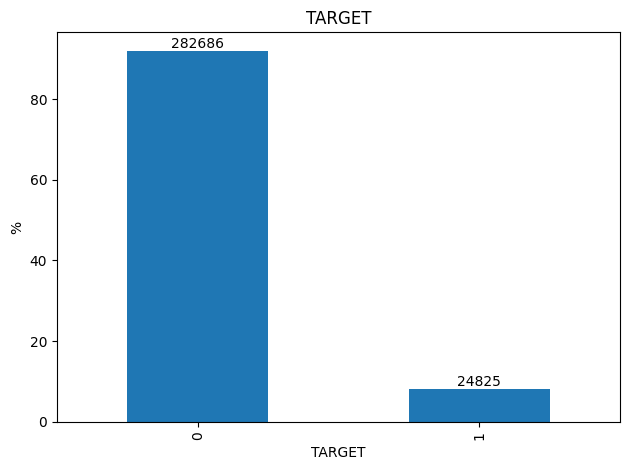


------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


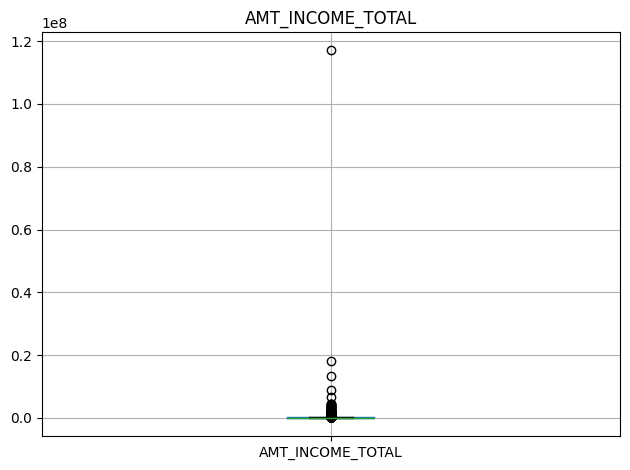

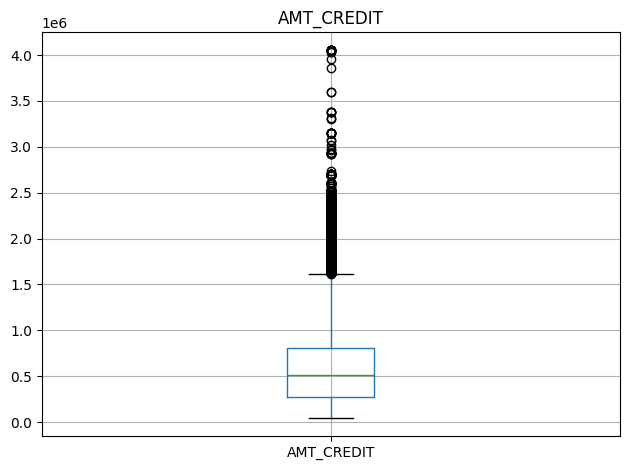

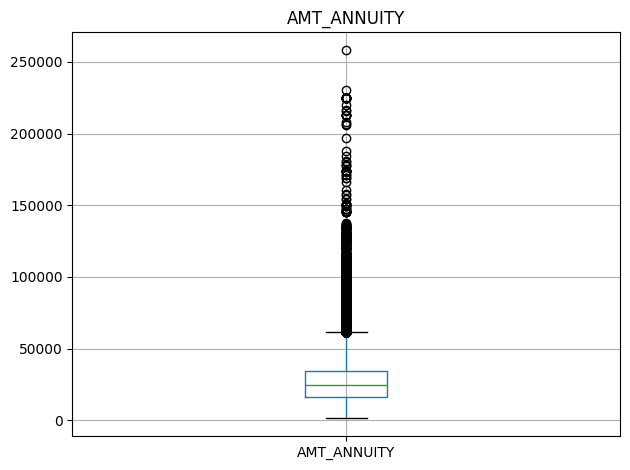

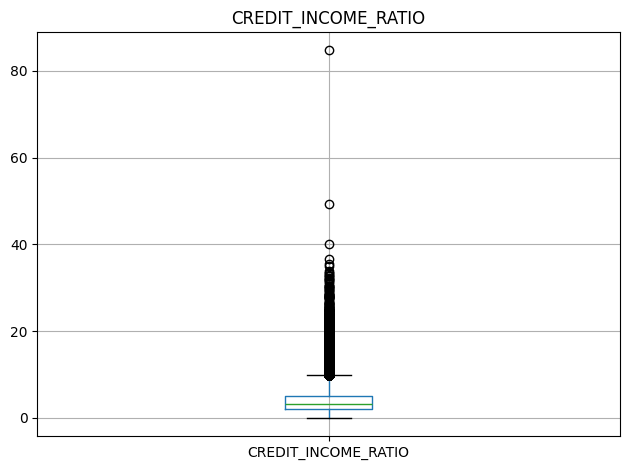

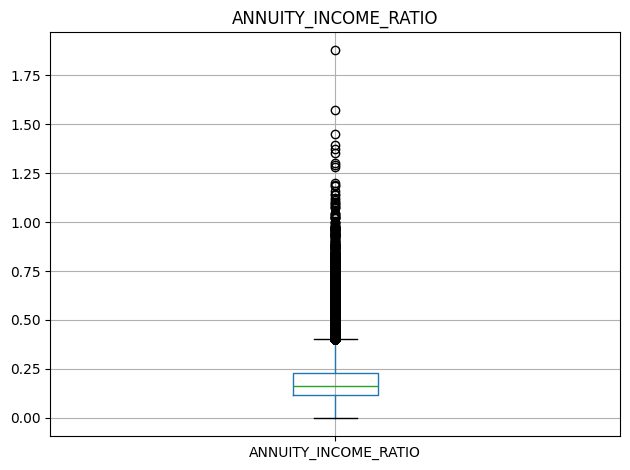

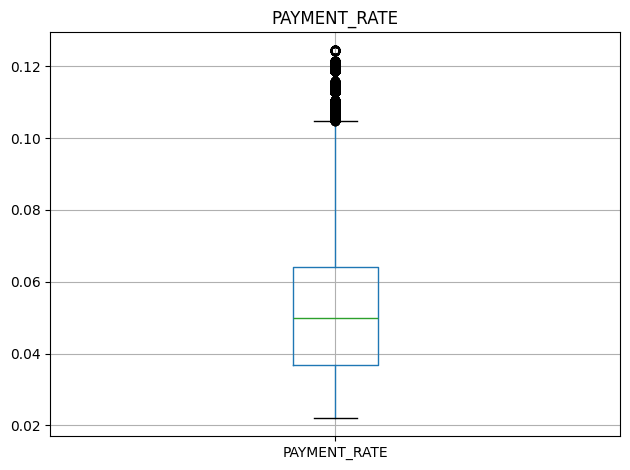

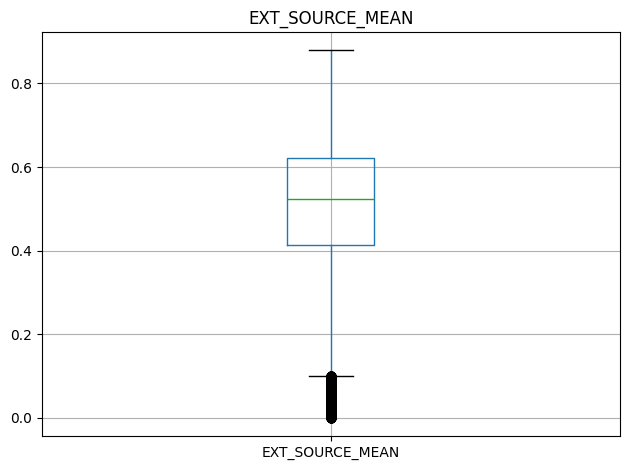

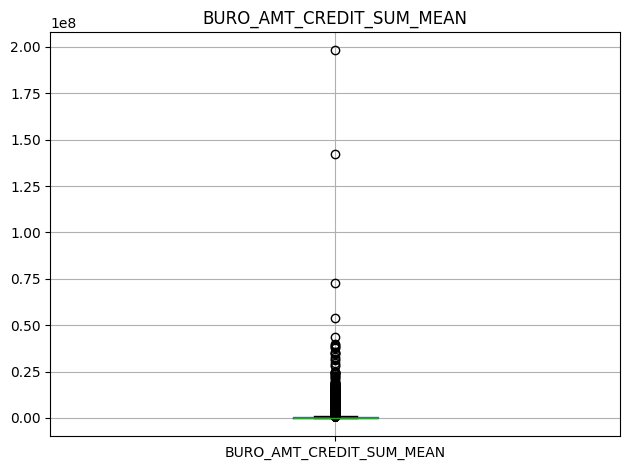

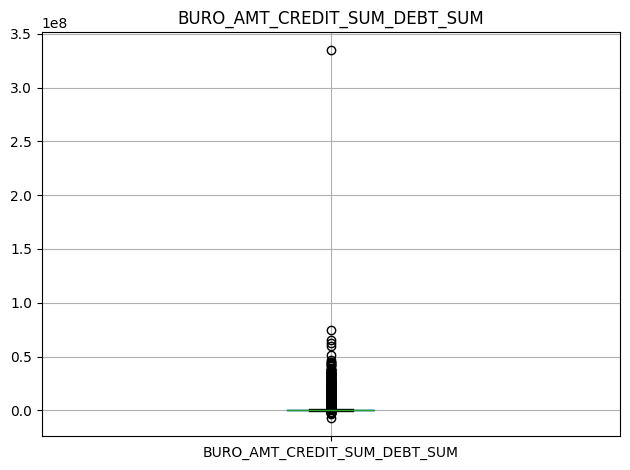

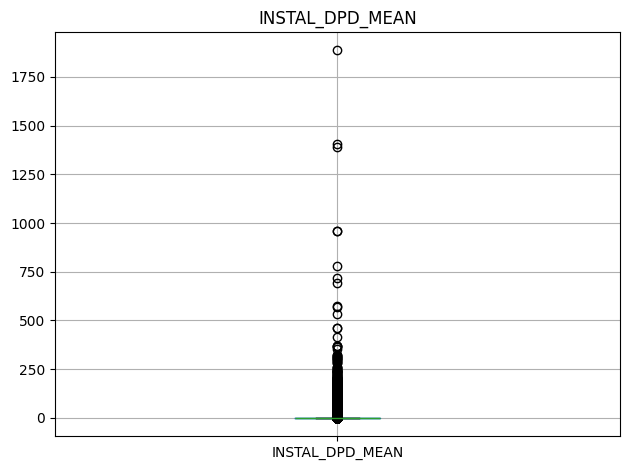

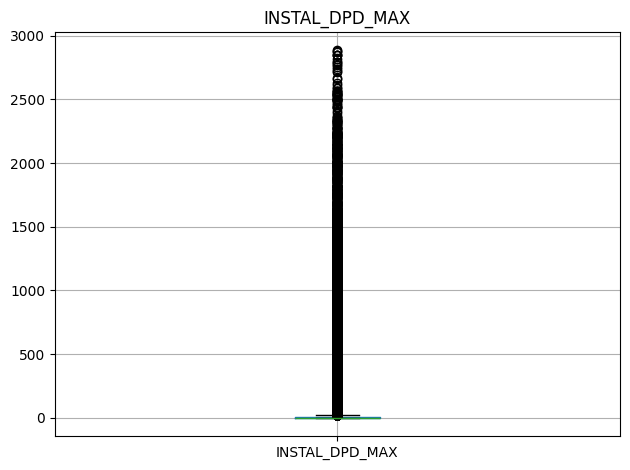

In [ ]:
# =========================================
# BASE APPLICATION
# =========================================

# Copie du dataset principal
feature_engineering = application_train.copy()

# Correction anomalie DAYS_EMPLOYED (valeur aberrante connue)
feature_engineering["DAYS_EMPLOYED_ANOM"] = (
    feature_engineering["DAYS_EMPLOYED"] == 365243                                    # Flag anomalie
)
feature_engineering["DAYS_EMPLOYED"] = (
    feature_engineering["DAYS_EMPLOYED"].replace(365243, np.nan)                      # Remplacement par NA
)

# Variables temporelles (plus interprétables)
feature_engineering["AGE"] = -feature_engineering["DAYS_BIRTH"]                       # Âge en jours (positif)
feature_engineering["YEARS_EMPLOYED"] = (
    -feature_engineering["DAYS_EMPLOYED"] / 365                                       # Ancienneté en années
)

# Ratios financiers (très importants pour le risque)
feature_engineering["CREDIT_INCOME_RATIO"] = (
    feature_engineering["AMT_CREDIT"] / feature_engineering["AMT_INCOME_TOTAL"]       # Niveau d’endettement
)
feature_engineering["ANNUITY_INCOME_RATIO"] = (
    feature_engineering["AMT_ANNUITY"] / feature_engineering["AMT_INCOME_TOTAL"]      # Charge mensuelle
)
feature_engineering["PAYMENT_RATE"] = (
    feature_engineering["AMT_ANNUITY"] / feature_engineering["AMT_CREDIT"]            # Proxy durée crédit
)
feature_engineering["INCOME_PER_PERSON"] = (
    feature_engineering["AMT_INCOME_TOTAL"] / feature_engineering["CNT_FAM_MEMBERS"]  # Revenu par personne
)

# Moyenne des scores externes → très prédictif
feature_engineering["EXT_SOURCE_MEAN"] = feature_engineering[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].mean(axis=1)

# Encodage des variables catégorielles
feature_engineering = one_hot_encoder(feature_engineering)

print("Application:", feature_engineering.shape)


# =========================================
# BUREAU (historique crédit externe)
# =========================================

bureau_df = one_hot_encoder(bureau.copy())                                            # Encodage

# Agrégations par client
bureau_agg = bureau_df.groupby("SK_ID_CURR").agg({
    "AMT_CREDIT_SUM": ["mean", "sum"],                                                # Montant crédit
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],                                           # Dette
    "DAYS_CREDIT": ["min", "mean"],                                                   # Historique crédit
    "CREDIT_DAY_OVERDUE": ["max", "mean"]                                             # Retards
})

# Renommage des colonnes
bureau_agg.columns = ["BURO_" + "_".join(col).upper() for col in bureau_agg.columns]

# Jointure avec dataset principal
feature_engineering = feature_engineering.join(
    bureau_agg, how="left", on="SK_ID_CURR"
)

# Nettoyage mémoire
del bureau_df, bureau_agg
gc.collect()


# =========================================
# PREVIOUS APPLICATION (historique demandes)
# =========================================

prev = one_hot_encoder(previous_application.copy())                                   # Encodage

# Ratio demandé / obtenu
prev["APP_CREDIT_PERC"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]

# Agrégations
prev_agg = prev.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean"],
    "AMT_CREDIT": ["mean"],
    "APP_CREDIT_PERC": ["mean"],
    "CNT_PAYMENT": ["mean"]
})

# Renommage
prev_agg.columns = ["PREV_" + "_".join(col).upper() for col in prev_agg.columns]

# Jointure
feature_engineering = feature_engineering.join(
    prev_agg, how="left", on="SK_ID_CURR"
)

# Nettoyage mémoire
del prev, prev_agg
gc.collect()


# =========================================
# INSTALLMENTS (comportement paiement)
# =========================================

ins = installments_payments.copy()

# % payé vs dû
ins["PAYMENT_PERC"] = ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"]

# Retard de paiement
ins["DPD"] = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]
ins["DPD"] = ins["DPD"].apply(lambda x: x if x > 0 else 0)                            # On garde seulement les retards

# Agrégations
ins_agg = ins.groupby("SK_ID_CURR").agg({
    "PAYMENT_PERC": ["mean"],                                                         # Qualité de paiement
    "DPD": ["max", "mean", "sum"]                                                     # Retards
})

# Renommage
ins_agg.columns = ["INSTAL_" + "_".join(col).upper() for col in ins_agg.columns]

# Jointure
feature_engineering = feature_engineering.join(
    ins_agg, how="left", on="SK_ID_CURR"
)

# Nettoyage mémoire
del ins, ins_agg
gc.collect()

eda(
    feature_engineering,
    name="feature_engineering",
    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "NAME_INCOME_TYPE",
        "NAME_FAMILY_STATUS",
        "CODE_GENDER"
    ],

    show_barplots=True,
    barplot_cols=[
        "TARGET"
    ],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "PAYMENT_RATE",
        "EXT_SOURCE_MEAN",
        "BURO_AMT_CREDIT_SUM_MEAN",
        "BURO_AMT_CREDIT_SUM_DEBT_SUM",
        "INSTAL_DPD_MEAN",
        "INSTAL_DPD_MAX"
    ]
)

#### **Structure générale du dataset**

Le dataset final contient 307 511 observations pour 286 variables. Il est construit autour de la table principale `application_train`, enrichie avec des variables issues du feature engineering et d’agrégations multi-tables.

On observe trois grandes familles de variables :

* variables brutes initiales (revenu, crédit, données démographiques)
* variables dérivées (ratios, transformations temporelles)
* variables agrégées issues des historiques (`BURO_*`, `PREV_*`, `INSTAL_*`)
* variables encodées (one-hot encoding des catégories)

#### **Feature engineering réalisé**

Le feature engineering enrichit fortement l’information initiale grâce à :

* transformation des variables temporelles  
  (âge, ancienneté en années)

* traitement d’anomalies métier  
  (`DAYS_EMPLOYED = 365243` remplacé et transformé en indicateur)

* création de ratios financiers très informatifs :
  * `CREDIT_INCOME_RATIO`
  * `ANNUITY_INCOME_RATIO`
  * `PAYMENT_RATE`
  * `INCOME_PER_PERSON`

* combinaison des scores externes :
  * `EXT_SOURCE_MEAN` (fort signal prédictif)

* intégration de signaux comportementaux via agrégations :
  * historique bureau (`BURO_*`)
  * historique des demandes (`PREV_*`)
  * comportement de paiement (`INSTAL_*`)

#### **Qualité des données**

Plusieurs points ressortent :

* un taux élevé de valeurs manquantes persiste pour certaines variables logement (\~60–70%)
* présence de nombreuses variables binaires issues du one-hot encoding
* certaines colonnes sont fortement déséquilibrées ou quasi constantes (flags, catégories rares)
* introduction de valeurs extrêmes ou infinies (ex : `INSTAL_PAYMENT_PERC_MEAN = inf`)

Ces éléments indiquent la nécessité :

* d’un nettoyage ou filtrage de certaines features
* d’un contrôle des valeurs aberrantes

#### **ariables numériques**

Les variables numériques montrent :

* forte dispersion sur les montants (revenus, crédits)
* distributions asymétriques (beaucoup de valeurs faibles et quelques extrêmes)
* variables comportementales intéressantes :
  * `INSTAL_DPD_*` (retards de paiement)
  * ratios financiers (endettement, capacité de remboursement)

Ces variables sont généralement les plus prédictives dans les modèles de scoring.

### **Variables catégorielles**
#
Après encodage :

* explosion du nombre de colonnes (one-hot encoding)
* transformation des variables catégorielles en variables binaires
* disparition des colonnes d’origine (difficile d’analyse directe)

Certaines catégories restent peu représentées et peuvent introduire du bruit.

#### **Variables issues des historiques**

Les features multi-tables apportent un gain important :

* `BURO_*` : situation d’endettement externe
* `PREV_*` : comportement passé vis-à-vis du crédit
* `INSTAL_*` : discipline de paiement

Ces variables capturent le risque client de manière dynamique et sont essentielles pour la performance du modèle.

#### **Points de vigilance**

* présence de valeurs infinies (`inf`) à traiter avant modélisation
* nombreuses features peu informatives (one-hot rares)
* variables très corrélées (notamment ratios et montants)
* possible surapprentissage dû au grand nombre de variables

#### **Conclusion**

Le dataset final est riche et combine :

* informations socio-économiques
* ratios financiers pertinents
* historique comportemental client

Le feature engineering améliore significativement la qualité du signal, notamment grâce aux données historiques.

Les prochaines étapes doivent se concentrer sur :

* nettoyage des valeurs extrêmes
* réduction de dimension (feature selection)
* comparaison de modèles pour exploiter efficacement cette richesse de variables

In [ ]:
# SAVE
feature_engineering.to_parquet(
    os.path.join(PROCESSED_PATH, "feature_engineering.parquet")
)

In [ ]:
# # LOAD
# feature_engineering = pd.read_parquet(
#     os.path.join(PROCESSED_PATH, "feature_engineering.parquet")
# )

### **3.2. Préparation pour modélisations futures**

In [ ]:
# Séparation features / target
X_raw = feature_engineering.drop(columns=["TARGET", "SK_ID_CURR"])  # features uniquement
y = feature_engineering["TARGET"]                                   # target

print("X_raw shape :", X_raw.shape)
print("y shape :", y.shape)

X_raw shape : (307511, 284)
y shape : (307511,)


In [ ]:
# Copie pour garder version brute
X_clean = X_raw.copy()

# Gestion des valeurs infinies : emplacement des inf par NaN
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

# Gestion des valeurs manquantes : emplacement simple des NA (baseline)
X_clean = X_clean.fillna(0)

# Suppression des colonnes constantes
constant_cols = X_clean.nunique() <= 1
print("Colonnes constantes supprimées :", constant_cols.sum())

X_clean = X_clean.loc[:, ~constant_cols]

# Contrôle final
print("X_clean shape :", X_clean.shape)
print("Nb NaN restants :", X_clean.isna().sum().sum())

Colonnes constantes supprimées : 10
X_clean shape : (307511, 274)
Nb NaN restants : 0


In [ ]:
# Réduction corrélation forte

corr_matrix = X_clean.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.99)]

print("Colonnes supprimées (corrélation forte) :", len(to_drop))

X_clean = X_clean.drop(columns=to_drop)

print("X_clean final :", X_clean.shape)

Colonnes supprimées (corrélation forte) : 28
X_clean final : (307511, 246)


In [ ]:
# SAVE
X_clean.to_parquet(
    os.path.join(PROCESSED_PATH, "X_clean.parquet")
)

y.to_frame().to_parquet(
    os.path.join(PROCESSED_PATH, "y.parquet")
)

### **3.3. LOAD**

In [ ]:
# LOAD
X_clean = pd.read_parquet(
    os.path.join(PROCESSED_PATH, "X_clean.parquet")
)
y = pd.read_parquet(
    os.path.join(PROCESSED_PATH, "y.parquet")
)

## **4. MODELING**

### **4.1. Fonctions génériques**

#### **4.1.1. Metrics business**

In [ ]:
def compute_business_cost(y_true, y_pred, fn_weight=10, fp_weight=1):
    """
    Calcule le coût métier basé sur :
    - FP : False Positive : bon client prédit mauvais
    - FN : False Negative : mauvais client prédit bon client

    Paramètres :
    - y_true : valeurs réelles (0/1)
    - y_pred : prédictions binaires (0/1)
    - fn_weight : poids des faux négatifs (défaut non détecté)
    - fp_weight : poids des faux positifs (bon client refusé)

    Retour :
    - business_cost (float) :
        coût total pondéré des erreurs de classification.
        Calcul = (fn_weight × nombre de FN) + (fp_weight × nombre de FP)

        → Plus la valeur est élevée, plus le modèle est mauvais du point de vue métier.
        → La valeur est non normalisée (dépend du nombre d'observations)
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel() # Matrice de confusion pour récupérer facilement FP et FN
    business_cost = fn_weight * fn + fp_weight * fp           # Coût métier : FN pénalisé fortement (perte financière réelle) / FP pénalisé faiblement (manque à gagner)

In [ ]:
def optimize_threshold(y_true, y_proba, fn_weight=10, fp_weight=1, n_thresholds=100):
    """
    Trouve le seuil optimal minimisant le coût métier.

    Paramètres :
    - y_true : valeurs réelles
    - y_proba : probabilités du modèle
    - fn_weight : coût FN (important métier)
    - fp_weight : coût FP
    - n_thresholds : nombre de seuils testés (précision vs temps)


    Retour :
    - best_threshold (float) :
        seuil optimal pour le modèle, minimisant le coût métier

    - best_cost (float) :
        coût métier minimum atteint par le modèle
        (correspond au best_threshold)

    - results_df (DataFrame) :
        tableau contenant :
        - tous les seuils testés
        - le coût métier associé à chaque seuil
        → permet d’analyser la sensibilité du coût au seuil
        → utile pour visualisation (courbe seuil vs coût)
    """

    # On teste plusieurs seuils entre 0 et 1
    # → permet de remplacer le seuil par défaut (0.5)
    thresholds = np.linspace(0, 1, n_thresholds)

    results = []

    for threshold in thresholds:

        # Transformation des probabilités en classes
        # → dépend du seuil testé
        y_pred = (y_proba > threshold).astype(int)

        # Calcul du coût métier pour ce seuil
        cost = compute_business_cost(
            y_true, y_pred,
            fn_weight=fn_weight,
            fp_weight=fp_weight
        )

        # Stockage pour analyse et comparaison
        results.append({
            "threshold": threshold,
            "business_cost": cost
        })

    # Conversion en DataFrame → utile pour analyse graphique
    results_df = pd.DataFrame(results)

    # Sélection du seuil minimisant le coût métier
    best_row = results_df.loc[results_df["business_cost"].idxmin()]

    best_threshold = best_row["threshold"]
    best_cost = best_row["business_cost"]

    return best_threshold, best_cost, results_df

#### **4.1.2. Pipeline d’entraînement**

In [ ]:
def split_data(X, y, test_size=0.2, random_state=42):
    """
    Sépare les données en train / validation.

    Objectif :
    - entraîner sur une partie des données
    - évaluer sur une autre (généralisation du modèle)

    Choix techniques :
    - stratify=y : conserve la proportion de la classe minoritaire (~8%)
    - test_size=0.2 : compromis classique (80% train / 20% validation)
    - random_state : reproductibilité

    Choix métier :
    - dataset déséquilibré → il est crucial de garder la même distribution

    Retour :
    - X_train : DataFrames des variables explicatives pour l'entraînement
    - X_val : DataFrames des variables explicatives pour la validation
    - y_train : Series de la variable cible pour l'entraînement
    - y_val : Series de la variable cible pour la validation

    → Les données sont séparées de façon aléatoire mais stratifiée,
      ce qui garantit que la proportion des classes (ex : défaut / non défaut)
      est similaire entre train et validation.

    → Les tailles dépendent de test_size :
      - train : (1 - test_size)
      - validation : test_size
    """

    return train_test_split(
        X,                        # données d'entrée (features)
        y,                        # variable cible à prédire
        stratify=y,               # conserve la proportion des classes
        test_size=test_size,      # taille du jeu de validation (ex : 20%)
        random_state=random_state # garantit un split reproductible
    )

In [ ]:
def scale_data(X_train, X_val):
    """
    Standardise les variables (centrage + réduction).

    Objectif :
    - rendre les variables comparables (même échelle)
    - améliorer la stabilité et la performance des modèles sensibles aux échelles

    Choix techniques :
    - StandardScaler → transforme chaque variable : moyenne = 0, écart-type = 1
    - fit uniquement sur X_train → calcule moyenne et écart-type sur le train seulement
    - transform sur X_val → applique les mêmes paramètres sans recalcul (évite le data leakage)
    - reconstruction en DataFrame → conservation des noms de colonnes et des index

    Choix métier :
    - aucun direct → transformation purement technique
    - impact indirect : améliore la qualité du modèle donc la décision métier

    Retour :
    - X_train_scaled : DataFrame des variables d'entraînement standardisées avec noms de colonnes conservés
    - X_val_scaled : DataFrame des variables de validation standardisées avec les mêmes paramètres que le train
    """

    scaler = StandardScaler()                       # initialise l'objet de normalisation (apprendra moyenne et écart-type)
    X_train_scaled = scaler.fit_transform(X_train)  # apprend les statistiques sur X_train puis applique la transformation
    X_val_scaled = scaler.transform(X_val)          # applique la transformation sur X_val avec les mêmes paramètres (pas de fit)

    X_train_scaled = pd.DataFrame(                  # reconstruit un DataFrame pour garder noms de colonnes et index
        X_train_scaled,
        columns=X_train.columns,
        index=X_train.index
    )

    X_val_scaled = pd.DataFrame(                    # même reconstruction pour cohérence avec le train
        X_val_scaled,
        columns=X_val.columns,
        index=X_val.index
    )

    return X_train_scaled, X_val_scaled

In [ ]:
def train_model_cv(model, param_grid, X_train, y_train):
    """
    Entraîne un modèle avec validation croisée et sélection automatique
    des meilleurs hyperparamètres.

    Objectif :
    - apprendre plusieurs versions du modèle avec différentes configurations
    - identifier celle qui généralise le mieux
    - retourner un modèle déjà entraîné et optimisé

    Choix techniques :
    - StratifiedKFold → conserve la proportion de défauts dans chaque fold
    - validation croisée à 5 folds → évaluation plus robuste qu'un simple split
    - GridSearchCV → teste toutes les combinaisons d'hyperparamètres
    - scoring="roc_auc" → comparaison basée sur la capacité à classer les clients
      du plus risqué au moins risqué
    - n_jobs=-1 → parallélisation des calculs

    Choix métier :
    - l'objectif ici est uniquement de trouver le meilleur modèle technique
    - le coût métier n'est pas encore pris en compte car il dépend du seuil
    - l'optimisation métier sera réalisée après obtention des probabilités

    Retour :
    - best_model : meilleur modèle entraîné sur l'ensemble du train
    - best_params : hyperparamètres ayant obtenu la meilleure AUC
    """
    cv = StratifiedKFold(
        n_splits=5,             # découpe les données en 5 folds pour la validation croisée
        shuffle=True,           # mélange les données avant découpage pour éviter un biais d'ordre
        random_state=42         # garantit la reproductibilité des splits
    )

    grid = GridSearchCV(
        estimator=model,        # modèle à entraîner et optimiser
        param_grid=param_grid,  # grille des hyperparamètres à tester
        scoring="roc_auc",      # métrique utilisée pour comparer les modèles (indépendante du seuil)
        cv=cv,                  # stratégie de validation croisée définie ci-dessus
        n_jobs=-1,              # utilise tous les cœurs CPU pour accélérer le calcul
        verbose=1               # affiche la progression de la recherche
    )

    grid.fit(X_train, y_train)  # entraîne tous les modèles (toutes combinaisons d’hyperparamètres) avec validation croisée

    return grid.best_estimator_, grid.best_params_  # renvoie le meilleur modèle déjà entraîné trouvé et ses hyperparamètres associés

In [ ]:
def predict_proba(model, X_val):
    """
    Génère les probabilités de défaut pour chaque client sur le dataset de val.

    Objectif :
    - estimer le risque de défaut client
    - produire un score exploitable pour l'AUC et les décisions métier

    Choix techniques :
    - predict_proba retourne une probabilité pour chaque classe :
        [P(classe 0), P(classe 1)]
    - seule la probabilité de la classe positive (TARGET=1) est conservée
    - aucune décision n'est encore prise à ce stade

    Choix métier :
    - la probabilité permet d'évaluer finement le risque client
    - la décision d'accepter ou refuser sera prise plus tard via un seuil

    Retour :
    - tableau de probabilités de défaut compris entre 0 et 1
    - une valeur par client :
        0   → risque très faible
        1   → risque très élevé
    """

  return model.predict_proba(X_val)[:, 1] # Garde uniquement P(TARGET = 1) = probabilité de défaut

In [ ]:
def evaluate_auc(y_val, y_proba):
    """
    Calcule l'AUC (Area Under the ROC Curve).

    Objectif :
    - mesurer la capacité du modèle à classer les clients du plus risqué au moins risqué
    - évaluer la qualité des scores de risque produits par le modèle

    Choix techniques :
    - compare les probabilités prédites (y_proba) aux vraies classes (y_val)
    - utilise les probabilités directement, sans transformer en 0/1
    - indépendant de tout seuil de décision
    - adapté aux jeux de données déséquilibrés

    Interprétation :
    L'AUC ne vérifie pas si les probabilités sont exactes, elle vérifie si les clients réellement en défaut reçoivent
    généralement des probabilités plus élevées que les autres, elle mesure donc la qualité du classement des risques

    Exemple :
    y_val   = [0, 1, 0, 1]
    y_proba = [0.10, 0.80, 0.20, 0.90]

    Les clients en défaut reçoivent les scores les plus élevés : classement parfait → AUC = 1.0

    Choix métier :
    - utile pour comparer plusieurs modèles de manière neutre
    - ne représente pas directement le coût financier réel
    - ne permet pas à lui seul de prendre une décision d'acceptation/refus

    Retour :
    - score AUC compris entre 0 et 1

        1.0  → séparation parfaite
        0.5  → modèle aléatoire
        <0.5 → classement inversé

    - plus l'AUC est élevée, plus le modèle distingue correctement les clients risqués des clients non risqués
    """

    return roc_auc_score(y_val, y_proba)    # Compare les probabilités prédites aux vraies classes et mesure la qualité du classement des clients par risque.

In [ ]:
def log_mlflow(model, best_params, auc, cost, threshold, X, scale, model_name):
    """
    Enregistre une expérience de machine learning dans MLflow.

    Objectif :
    - conserver un historique complet des expérimentations
    - comparer facilement plusieurs modèles et configurations
    - assurer la traçabilité des résultats
    - sauvegarder le modèle entraîné pour une réutilisation future (batch, API, monitoring)

    Choix techniques :
    - création d'un run MLflow identifié par le nom du modèle et la version des features
    - journalisation des paramètres d'entraînement :
        * type de modèle
        * hyperparamètres optimaux
        * nombre de features
        * utilisation du scaling
    - journalisation des métriques :
        * AUC
        * coût métier
        * seuil optimal
    - sauvegarde du modèle entraîné comme artefact MLflow

    Choix métier :
    - permet de comparer les performances techniques et les performances métier
    - garantit la reproductibilité des résultats
    - facilite le déploiement du meilleur modèle
    - permet de savoir précisément quelle version du modèle a été utilisée en production

    Retour :
    - aucun retour (None)
    - les informations sont enregistrées dans le serveur ou le stockage MLflow configuré
    """
    if RUN_MLFLOW:

        RUN_VERSION = "v1"               # Version du modèle entraîné
        FEATURE_VERSION = "features_v1"  # Version du feature engineering

        # Démarre un nouvel enregistrement MLflow
        with mlflow.start_run(
            run_name=f"{model_name}_{FEATURE_VERSION}_{RUN_VERSION}"
        ):

            # Paramètres utilisés pour l'entraînement
            mlflow.log_param("model", model.__class__.__name__)
            mlflow.log_param("best_params", str(best_params))
            mlflow.log_param("n_features", X.shape[1])
            mlflow.log_param("scale", scale)
            mlflow.log_param("feature_version", FEATURE_VERSION)

            # Résultats obtenus par le modèle
            mlflow.log_metric("auc", auc)
            mlflow.log_metric("business_cost", cost)
            mlflow.log_metric("threshold", threshold)

            # Sauvegarde le modèle entraîné pour réutilisation future
            mlflow.sklearn.log_model(model, name="model")

In [ ]:
def run_model(
    model,
    param_grid,
    X,
    y,
    model_name="model",
    scale=False
):
    """
    Exécute le pipeline complet d'entraînement et d'évaluation d'un modèle.

    Objectif :
    - entraîner un modèle de scoring de bout en bout
    - comparer les performances techniques et métier
    - produire un modèle prêt à être enregistré et réutilisé

    Choix techniques :
    - séparation train / validation pour évaluer la généralisation
    - scaling optionnel selon les besoins du modèle
    - validation croisée + recherche d'hyperparamètres
    - évaluation par AUC à partir des probabilités prédites
    - optimisation du seuil pour minimiser le coût métier

    Choix métier :
    - séparation entre qualité du modèle (AUC) et qualité de la décision (coût métier)
    - recherche du seuil le plus rentable
    - traçabilité complète via MLflow

    Retour :
    - results : dictionnaire standardisé contenant :
        * modèle
        * AUC
        * coût métier
        * seuil optimal
        * hyperparamètres optimaux

    - optimized_model : meilleur modèle entraîné
    """
    # 1. Split train / validation
    X_train, X_val, y_train, y_val = split_data(X, y)

    # 2. Scaling optionnel
    if scale:
        X_train, X_val = scale_data(X_train, X_val)

    # 3. Entraînement + optimisation des hyperparamètres
    optimized_model, best_params = train_model_cv(
        model,
        param_grid,
        X_train,
        y_train
    )

    # 4. Estimation du risque pour chaque observation
    y_proba = predict_proba(optimized_model, X_val)

    # 5. Qualité du classement des observations
    auc = evaluate_auc(y_val, y_proba)

    # 6. Recherche du seuil minimisant le coût métier
    threshold, cost = compute_business_metrics(
        y_val,
        y_proba
    )

    # 7. Sauvegarde de l'expérience dans MLflow
    log_mlflow(
        optimized_model,
        best_params,
        auc,
        cost,
        threshold,
        X,
        scale,
        model_name
    )

    # 8. Résumé standardisé des résultats
    results = {
        "model": model_name,
        "auc": auc,
        "business_cost": cost,
        "threshold": threshold,
        "best_params": best_params
    }

    print(results)

    return results, optimized_model

#### **4.1.3. Analyses**

In [ ]:
def global_feature_importance(model, X, top_n=20):
    """
    Analyse l'importance globale des variables.

    Objectif :
    - identifier les variables les plus influentes dans le modèle
    - comprendre les drivers principaux du risque

    Choix techniques :
    - utilisation de feature_importances_ (modèles arbres)
    - tri décroissant pour visualisation

    Limite :
    - ne donne pas le sens (positif/négatif)
    - dépend du type de modèle

    Choix métier :
    - permet d’identifier les facteurs de risque principaux
    - utile pour interprétation globale et présentation
    """

    # Récupération des importances
    importances = model.feature_importances_

    # Création DataFrame
    fi_df = pd.DataFrame({
        "feature": X.columns,
        "importance": importances
    })

    # Tri décroissant
    fi_df = fi_df.sort_values("importance", ascending=False)

    # Affichage top variables
    print(fi_df.head(top_n))

    # Visualisation
    fi_df.head(top_n).plot.barh(
        x="feature",
        y="importance",
        figsize=(8, 6)
    )

    return fi_df

In [ ]:
def local_feature_analysis(model, X, y_proba, n_random=2):
    """
    Analyse de cas individuels.

    Objectif :
    - comprendre pourquoi un client est classé à risque ou non
    - apporter une explicabilité locale

    Cas analysés :
    - probabilité max (client très risqué)
    - probabilité min (client très sûr)
    - probabilité médiane
    - cas aléatoires

    Choix technique :
    - sélection basée sur y_proba
    - approche simple sans SHAP (plus rapide)

    Choix métier :
    - permet d’expliquer des décisions individuelles
    - utile pour API et confiance utilisateur
    """

    df = pd.DataFrame({
        "proba": y_proba
    })

    # Sélection des cas intéressants
    idx_max = df["proba"].idxmax()
    idx_min = df["proba"].idxmin()
    idx_med = (df["proba"] - df["proba"].median()).abs().idxmin()

    idx_random = np.random.choice(df.index, n_random, replace=False)

    selected_idx = [idx_max, idx_min, idx_med] + list(idx_random)

    print("Index sélectionnés :", selected_idx)

    # Affichage des features associées
    for idx in selected_idx:
        print("\n--- Client index :", idx)
        print("Probabilité :", y_proba[idx])
        print(X.iloc[idx])

In [ ]:
def global_model_analysis(y_val, y_proba, threshold):
    """
    Analyse globale du modèle.

    Objectif :
    - comprendre la distribution des scores
    - analyser les erreurs (FN / FP)
    - relier performance technique et impact métier

    Choix techniques :
    - histogramme des probabilités
    - confusion matrix basée sur threshold optimisé

    Choix métier :
    - FN = erreurs critiques (défaut non détecté)
    - FP = erreurs acceptables (client refusé)

    → permet de valider l’adéquation du modèle au besoin business
    """

    # ----------------------------
    # 1. Distribution des scores
    # ----------------------------
    plt.hist(y_proba, bins=50)
    plt.title("Distribution des probabilités")
    plt.xlabel("Probabilité de défaut")
    plt.ylabel("Fréquence")
    plt.show()

    # ----------------------------
    # 2. Prédictions avec seuil
    # ----------------------------
    y_pred = (y_proba > threshold).astype(int)

    # ----------------------------
    # 3. Matrice de confusion
    # ----------------------------
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    print("Confusion matrix :")
    print("TN :", tn)
    print("FP :", fp)
    print("FN :", fn)
    print("TP :", tp)

    # ----------------------------
    # 4. Interprétation métier
    # ----------------------------
    print("\nAnalyse métier :")
    print(f"Faux négatifs (FN) : {fn} → clients risqués non détectés (coût élevé)")
    print(f"Faux positifs (FP) : {fp} → clients refusés à tort (coût modéré)")

    print(f"\nSeuil utilisé : {threshold}")

### **4.2. Modèles**

#### **4.1.1. Baseline : DummyClassifier**

In [ ]:
# 1. Split des données
X_train, X_val, y_train, y_val = split_data(X_clean, y)


# 2. Modèle baseline
dummy = DummyClassifier(
    strategy="prior",   # prédit la proportion de la classe positive (~8%)
    random_state=42
)

dummy.fit(X_train, y_train)


# 3. Prédictions probabilistes
y_proba_dummy = predict_proba(dummy, X_val)


# 4. Évaluation AUC
auc_dummy = evaluate_auc(y_val, y_proba_dummy)


# 5. Optimisation métier (seuil)
threshold_dummy, cost_dummy = compute_business_metrics(
    y_val,
    y_proba_dummy
)


# 6. Logging MLflow (propre)
MODEL_NAME = "DummyClassifier"

log_mlflow(
    model=dummy,
    best_params={"strategy": "prior"},
    auc=auc_dummy,
    cost=cost_dummy,
    threshold=threshold_dummy,
    X=X_clean,
    scale=False,
    model_name=MODEL_NAME
)


# 7. Résultats standardisés
results_dummy = {
    "model": MODEL_NAME,
    "auc": auc_dummy,
    "business_cost": cost_dummy,
    "threshold": threshold_dummy,
    "best_params": {"strategy": "prior"}
}

print(results_dummy)

{'model': 'DummyClassifier', 'auc': np.float64(0.5), 'business_cost': np.float64(49650.0), 'threshold': np.float64(0.08080808080808081), 'best_params': {'strategy': 'prior'}}


#### **4.1.2. Modèle simple : LogisticRegression**

#### **4.1.3. Modèle complexe : LGBMClassifier**

### **4.3. Analyses**

#### **4.3.1. Feature importance globale**

#### **4.3.2. Feature importance locale**

#### **4.3.3. Synthèse générale**